In [21]:
import matplotlib.pyplot as plt
import astricaltools as at
import numpy as np
import pandas as pd
import scipy.stats as sc
from astropy import stats
import astropy.units as u
from astropy.io import fits
from astropy.table import vstack, Table
from astropy.time import Time
from astropy.timeseries import TimeSeries
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, Angle

In [22]:
file_numbers = range(1, 10)  # da 001 a 009
base_path = "astri_{:03d}_43_009_00002_R_201023_004_0201_SEB.lv0"  # pattern del nome file

dfs = []  # lista per accumulare i DataFrame
print("\n")
for i in file_numbers:
    filename = base_path.format(i)
    print(f"{filename}")

    with at.io.fits.AstriFits(filename) as hdul:
        data = hdul[1].data

        # Conversione dei campi
        time_ns = data["TIME_NS"].byteswap().newbyteorder().astype(np.int64)
        time_s  = data["TIME_S"].byteswap().newbyteorder().astype(np.int64)
        event   = data["EVTNUM"].byteswap().newbyteorder().astype(np.int64)
        mcrun   = data["MCRUNNUM"].byteswap().newbyteorder().astype(np.int64)
        ntel= data["NTRIGTEL"]
        time_abs = time_s * 10**9 + time_ns  # tempo assoluto in ns
        hg, lg, ttp = hdul.get_data('events', ['hi', 'lo', 'ttp'])
        time_abs = time_s * 10**9 + time_ns  # tempo assoluto in ns
            #creo il dataframe
        df = pd.DataFrame({
                "TIME_NS": time_ns,
                "TIME_S": time_s,
                "TIME_ABS": time_abs,
                "EVENT": event,
                "MCRUN": mcrun,
                "TEL_ID": i,
                "num_tel": ntel,
                "HG": list(hg),             
                "LG": list(lg),
                "TTP": list(ttp),
            })

        dfs.append(df)
df_all = pd.concat(dfs, ignore_index=True)
df_all_sorted= df_all.sort_values(by="TIME_ABS").reset_index(drop=True)
df_all_sorted["shape"] = df_all_sorted["HG"].apply(np.sum).to_numpy()
df
#print(df_all_sorted.head())
#print(len(df_all_sorted))




astri_001_43_009_00002_R_201023_004_0201_SEB.lv0
astri_002_43_009_00002_R_201023_004_0201_SEB.lv0
astri_003_43_009_00002_R_201023_004_0201_SEB.lv0
astri_004_43_009_00002_R_201023_004_0201_SEB.lv0
astri_005_43_009_00002_R_201023_004_0201_SEB.lv0
astri_006_43_009_00002_R_201023_004_0201_SEB.lv0
astri_007_43_009_00002_R_201023_004_0201_SEB.lv0
astri_008_43_009_00002_R_201023_004_0201_SEB.lv0
astri_009_43_009_00002_R_201023_004_0201_SEB.lv0


,TIME_NS,TIME_S,TIME_ABS,EVENT,MCRUN,TEL_ID,num_tel,HG,LG,TTP
0,1030456,0,1030456,3519,263210,9,2,"[[2126, 2121, 2134, 2208, 2194, 2174, 2226, 22...","[[2128, 2128, 2129, 2132, 2132, 2130, 2133, 21...","[[255, 255, 255, 255, 255, 255, 255, 255, 255,..."
1,3274338,0,3274338,3803,263210,9,1,"[[2110, 2200, 2063, 2231, 2197, 2243, 2190, 20...","[[2127, 2132, 2125, 2133, 2132, 2134, 2131, 21...","[[255, 255, 255, 255, 255, 255, 255, 255, 255,..."
2,3679960,0,3679960,3805,263210,9,8,"[[2109, 2063, 2115, 2171, 2186, 2107, 2261, 22...","[[2127, 2125, 2128, 2130, 2131, 2127, 2134, 21...","[[255, 255, 255, 255, 255, 255, 255, 255, 255,..."
3,6391145,0,6391145,1011,263211,9,1,"[[2085, 2210, 2268, 2181, 2261, 2070, 2185, 21...","[[2126, 2132, 2135, 2131, 2135, 2125, 2131, 21...","[[255, 255, 255, 255, 255, 255, 255, 255, 255,..."
4,10916501,0,10916501,1209,263211,9,1,"[[2126, 2191, 2261, 2007, 2195, 2182, 2129, 22...","[[2128, 2131, 2135, 2122, 2131, 2131, 2128, 21...","[[255, 255, 255, 255, 255, 255, 255, 255, 123,..."
...,...,...,...,...,...,...,...,...,...,...
3157,316424396,9,9316424396,7915,266398,9,8,"[[2152, 2187, 2166, 2148, 2147, 2127, 2174, 21...","[[2129, 2131, 2130, 2129, 2129, 2128, 2130, 21...","[[255, 255, 255, 255, 255, 255, 255, 255, 255,..."
3158,321000985,9,9321000985,8402,266398,9,9,"[[2113, 2050, 2263, 2073, 2132, 2078, 2293, 20...","[[2127, 2124, 2135, 2125, 2128, 2126, 2136, 21...","[[255, 255, 255, 158, 255, 255, 255, 255, 255,..."
3159,326043880,9,9326043880,1403,266399,9,9,"[[2385, 2234, 2198, 2229, 2154, 2125, 2167, 21...","[[2141, 2133, 2132, 2133, 2129, 2128, 2130, 21...","[[117, 255, 255, 255, 255, 255, 255, 255, 255,..."
3160,329345615,9,9329345615,2419,266399,9,6,"[[2147, 2090, 2225, 2220, 2201, 2126, 2132, 22...","[[2129, 2126, 2133, 2133, 2132, 2128, 2128, 21...","[[255, 255, 255, 255, 255, 255, 255, 255, 255,..."


In [38]:
def principal_axis(cov):
            l1 = (cov[0,0] + cov[1,1])/2 + np.sqrt(
                ((cov[0,0] - cov[1,1])/2)**2 + cov[0,1]**2)
            theta = np.arctan2(l1 - cov[0,0], cov[0,1])
            return l1, theta
#raccolgo i dati delle rette divisi per ogni (event,mcrun)
df_all_sorted=df_all_sorted[df_all_sorted["shape"]>5.16e6]
df_all_sorted=df_all_sorted[df_all_sorted["num_tel"]>=3]

print(len(df_all_sorted))

xfp, yfp = at.utils.camera.get_xy_footprint()
y_pix, x_pix = at.utils.camera.get_pixels_position_matrix().T
x_pix = at.reshape(x_pix)
y_pix = at.reshape(y_pix)

#rette_hg=[]
#rette_lg=[]
results = []

for (event, mcrun), df_evt in df_all_sorted.groupby(["EVENT", "MCRUN"]):

    for iv, row in df_evt.iterrows():

        itel = row["TEL_ID"]
        hgev = np.array(row["HG"])
        lgev = np.array(row["LG"])
        ttpev = np.array(row["TTP"])

        # filtro temporale
        pxmask = (hgev > 2400) & (ttpev < 255)
        if  np.sum(pxmask) == 0:
            continue
        # SIGMA-CLIPPING
    
        xx = x_pix[pxmask].flatten()
        yy = y_pix[pxmask].flatten()
        w_hg = hgev[pxmask].flatten()
        w_lg = lgev[pxmask].flatten()

        mx0 = np.average(xx, weights=w_hg)
        my0 = np.average(yy, weights=w_hg)

        r = np.sqrt((xx - mx0)**2 + (yy - my0)**2)

        r_clip, low, high = sc.sigmaclip(r, low=2., high=2.)
        keep = (r >= low) & (r <= high)

        xx_sc = xx[keep]
        yy_sc = yy[keep]
        w_hg_sc = w_hg[keep]
        w_lg_sc = w_lg[keep]
        # ---------- centroidi ----------
        meanx_hg = np.average(xx_sc, weights=w_hg_sc)
        meany_hg = np.average(yy_sc, weights=w_hg_sc)

        meanx_lg = np.average(xx_sc, weights=w_lg_sc)
        meany_lg = np.average(yy_sc, weights=w_lg_sc)

        # ---------- covarianze ----------
        cov_hg = np.cov([xx_sc, yy_sc], aweights=w_hg_sc)
        cov_lg = np.cov([xx_sc, yy_sc], aweights=w_lg_sc)
        # autovalori + direzione
        

        l1_hg, theta_hg = principal_axis(cov_hg)
        l1_lg, theta_lg = principal_axis(cov_lg)

        results.append({
            "event": event,
            "mcrun": mcrun,
            "HG": {
                "p0": np.array([meanx_hg, meany_hg]),
                "d":  np.array([np.cos(theta_hg), np.sin(theta_hg)]),
                "l1": l1_hg,
                "tel": itel
            },
            "LG": {
                "p0": np.array([meanx_lg, meany_lg]),
                "d":  np.array([np.cos(theta_lg), np.sin(theta_lg)]),
                "l1": l1_lg,
                "tel": itel
            }
        })


4213


In [24]:
def intersection(p1, d1, p2, d2):
    """
    p1, p2 = punti
    d1, d2 = direzioni
    """
    A = np.array([d1, -d2]).T
    b = p2 - p1

    det = np.linalg.det(A)
    if abs(det) < 1e-6:
        return None

    t = np.linalg.solve(A, b)[0]
    return p1 + t * d1


def d_punto_retta(P, p0, d):
    norm_d = np.linalg.norm(d)
    if norm_d == 0:
        return np.nan

    d_unit = d / norm_d
    v = P - p0
    return abs(v[0] * d_unit[1] - v[1] * d_unit[0])


def peso_angolare(d1, d2):
    d1 = d1 / np.linalg.norm(d1)
    d2 = d2 / np.linalg.norm(d2)
    return abs(d1[0]*d2[1] - d1[1]*d2[0])


# ======================= CALCOLO EVENTI VERI =======================

inters_hg = []
dist_hg = []
inters_lg = []
dist_lg = []

dfR = pd.DataFrame(results)
#'''
for (event, mcrun), df_evt in dfR.groupby(["event", "mcrun"]):

    rette_evth = df_evt["HG"].values
    rette_evtl = df_evt["LG"].values

    # ===================== HG =====================
    for i in range(len(rette_evth)):
        tel1 = rette_evth[i]["tel"]
        for j in range(i+1, len(rette_evth)):
            tel2 = rette_evth[j]["tel"]
            if tel1 == tel2:
                continue

            P = intersection(rette_evth[i]["p0"], rette_evth[i]["d"],
                             rette_evth[j]["p0"], rette_evth[j]["d"])
            if P is None:
                continue

            # filtro distanza radiale
            if np.linalg.norm(P) > 400:
                continue

            # centro media e mediana (qui P è singolo quindi media = mediana = P)
            centro_hg = P
            median_hg = P

            d_mean = []
            d_median = []

            for r in rette_evth:
                p0 = r["p0"]
                d  = r["d"]
                d_mean.append(d_punto_retta(centro_hg, p0, d))
                d_median.append(d_punto_retta(median_hg, p0, d))

            dist_hg.append({
                "event": event,
                "mcrun": mcrun,
                "d_mean": d_mean,
                "d_median": d_median
            })
            inters_hg.append({
                "event": event,
                "mcrun": mcrun,
                "P": P
            })

    # ===================== LG =====================
    for i in range(len(rette_evtl)):
        tel1 = rette_evtl[i]["tel"]
        for j in range(i+1, len(rette_evtl)):
            tel2 = rette_evtl[j]["tel"]
            if tel1 == tel2:
                continue

            P = intersection(rette_evtl[i]["p0"], rette_evtl[i]["d"],
                             rette_evtl[j]["p0"], rette_evtl[j]["d"])
            if P is None:
                continue

            if np.linalg.norm(P) > 400:
                continue

            centro_lg = P
            median_lg = P

            d_mean = []
            d_median = []

            for r in rette_evtl:
                p0 = r["p0"]
                d  = r["d"]
                d_mean.append(d_punto_retta(centro_lg, p0, d))
                d_median.append(d_punto_retta(median_lg, p0, d))

            dist_lg.append({
                "event": event,
                "mcrun": mcrun,
                "d_mean": d_mean,
                "d_median": d_median
            })
            inters_lg.append({
                "event": event,
                "mcrun": mcrun,
                "P": P
            })


# ===================== DATAFRAME FINALI =====================

df_int_hg = pd.DataFrame(inters_hg)
df_int_lg = pd.DataFrame(inters_lg)
df_dist_hg = pd.DataFrame(dist_hg)
df_dist_lg = pd.DataFrame(dist_lg)

P_hg = np.vstack(df_int_hg["P"].values)
P_lg = np.vstack(df_int_lg["P"].values)
#'''

In [37]:
def d_punto_retta_vec(P, p0, d):
    """
    Calcola distanza di più rette da un punto P
    P : (2,)
    p0: (N,2)
    d : (N,2)
    """
    norm_d = np.linalg.norm(d, axis=1)
    mask = norm_d > 0

    d_unit = np.zeros_like(d)
    d_unit[mask] = d[mask] / norm_d[mask, None]

    v = P - p0
    return np.abs(v[:, 0] * d_unit[:, 1] - v[:, 1] * d_unit[:, 0])

from sklearn.cluster import DBSCAN
# Parametri DBSCAN
epsilon = 5
min_samples = 1

# ======================= HG =======================
dist_hg = []

df_int_hg = pd.DataFrame(inters_hg)

for (event, mcrun), df_evt in df_int_hg.groupby(["event", "mcrun"]):

    # tutte le intersezioni dell'evento
    P = np.vstack(df_evt["P"].values)
    if P.shape[0] < min_samples:
        continue

    # DBSCAN
    labels = DBSCAN(eps=epsilon, min_samples=min_samples).fit_predict(P)
    cl_labels = set(labels) - {-1}
    if not cl_labels:
        continue

    # rette dell'evento
    dfR_evt = dfR.loc[(dfR["event"] == event) & (dfR["mcrun"] == mcrun),"HG"]

    p0  = np.array([r["p0"] for r in dfR_evt])
    d   = np.array([r["d"]  for r in dfR_evt])
    tel = np.array([r["tel"] for r in dfR_evt])

    # ciclo cluster
    for lab in cl_labels:
        Pcl = P[labels == lab]

        # media e mediana cluster
        P_mean   = np.mean(Pcl, axis=0)
        P_median = np.median(Pcl, axis=0)

        # distanza di ogni retta dalla media e dalla mediana
        dist_mean   = d_punto_retta_vec(P_mean,   p0, d)
        dist_median = d_punto_retta_vec(P_median, p0, d)

        # salva in DataFrame 
        for t, dm, dmed in zip(tel, dist_mean, dist_median):
            dist_hg.append({
                "event": event,
                "mcrun": mcrun,
                "cluster": lab,
                "tel": t,
                "P_mean": P_mean.copy(),
                "P_median": P_median.copy(),
                "d_mean": dm,
                "d_median": dmed
            })

df_dist_hg = pd.DataFrame(dist_hg)

# ======================= LG =======================
dist_lg = []

df_int_lg = pd.DataFrame(inters_lg)

for (event, mcrun), df_evt in df_int_lg.groupby(["event", "mcrun"]):

    P = np.vstack(df_evt["P"].values)
    if P.shape[0] < min_samples:
        continue

    labels = DBSCAN(eps=epsilon, min_samples=min_samples).fit_predict(P)
    cl_labels = set(labels) - {-1}
    if not cl_labels:
        continue

    dfR_evt = dfR.loc[
        (dfR["event"] == event) & (dfR["mcrun"] == mcrun),
        "LG"
    ]

    p0  = np.array([r["p0"] for r in dfR_evt])
    d   = np.array([r["d"]  for r in dfR_evt])
    tel = np.array([r["tel"] for r in dfR_evt])

    for lab in cl_labels:
        Pcl = P[labels == lab]

        P_mean   = np.mean(Pcl, axis=0)
        P_median = np.median(Pcl, axis=0)

        dist_mean   = d_punto_retta_vec(P_mean,   p0, d)
        dist_median = d_punto_retta_vec(P_median, p0, d)

        for t, dm, dmed in zip(tel, dist_mean, dist_median):
            dist_lg.append({
                "event": event,
                "mcrun": mcrun,
                "cluster": lab,
                "tel": t,
                "P_mean": P_mean.copy(),
                "P_median": P_median.copy(),
                "d_mean": dm,
                "d_median": dmed
            })

df_dist_lg = pd.DataFrame(dist_lg)

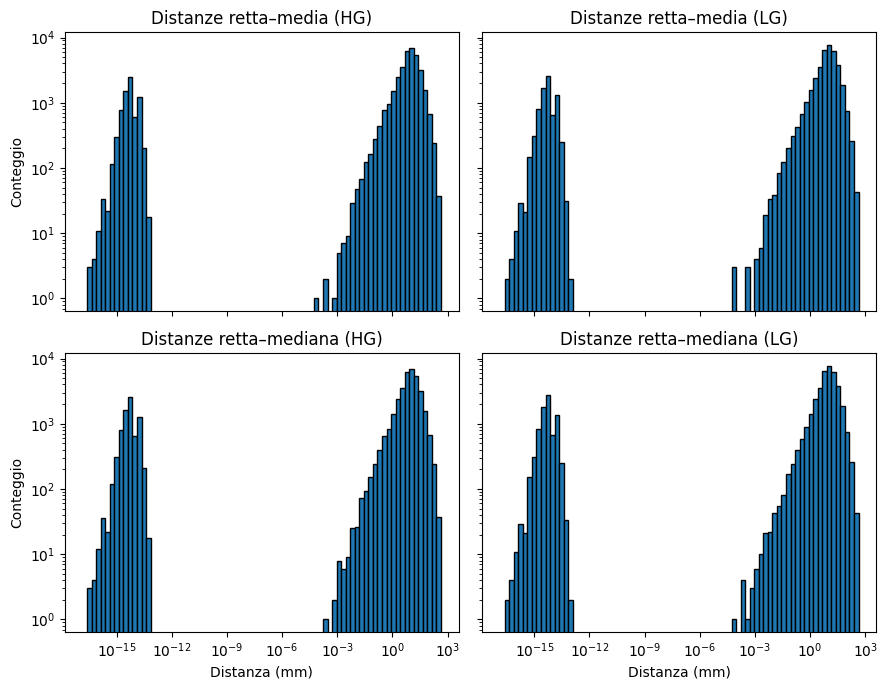

In [ ]:
# Istogramma distanze media-retta e mediana-retta per tutti gli eventi falsi
# -------------------------------------------------------------------------
'''
# concateno
d_mean_hg = np.concatenate(df_dist_hg["d_mean"].values)
d_median_hg = np.concatenate(df_dist_hg["d_median"].values)
d_mean_lg = np.concatenate(df_dist_lg["d_mean"].values)
d_median_lg = np.concatenate(df_dist_lg["d_median"].values)

# filtro valori validi (>0 e finiti)
d_mean_hg = d_mean_hg[np.isfinite(d_mean_hg) & (d_mean_hg > 0)]
d_median_hg = d_median_hg[np.isfinite(d_median_hg) & (d_median_hg > 0)]
d_mean_lg = d_mean_lg[np.isfinite(d_mean_lg) & (d_mean_lg > 0)]
d_median_lg = d_median_lg[np.isfinite(d_median_lg) & (d_median_lg > 0)]
'''
d_mean_hg   = df_dist_hg["d_mean"].values
d_median_hg = df_dist_hg["d_median"].values
d_mean_lg   = df_dist_lg["d_mean"].values
d_median_lg = df_dist_lg["d_median"].values

# filtro valori validi (>0 e finiti)
d_mean_hg   = d_mean_hg[np.isfinite(d_mean_hg) & (d_mean_hg > 0)]
d_median_hg = d_median_hg[np.isfinite(d_median_hg) & (d_median_hg > 0)]
d_mean_lg   = d_mean_lg[np.isfinite(d_mean_lg) & (d_mean_lg > 0)]
d_median_lg = d_median_lg[np.isfinite(d_median_lg) & (d_median_lg > 0)]

# binnaggio comune
d_all = np.concatenate([d_mean_hg, d_median_hg, d_mean_lg, d_median_lg])
bins = np.logspace(np.log10(d_all.min()), np.log10(d_all.max()), 80)

fig, axes = plt.subplots(2, 2, figsize=(9, 7), sharex=True, sharey=True)

# -------------------- HG --------------------
axes[0,0].hist(d_mean_hg, bins=bins, edgecolor='black')
axes[0,0].set_title("Distanze retta–media (HG)")
axes[0,0].set_ylabel("Conteggio")
axes[1,0].hist(d_median_hg, bins=bins, edgecolor='black')
axes[1,0].set_title("Distanze retta–mediana (HG)")
axes[1,0].set_ylabel("Conteggio")
axes[1,0].set_xlabel("Distanza (mm)")

# -------------------- LG --------------------
axes[0,1].hist(d_mean_lg, bins=bins, edgecolor='black')
axes[0,1].set_title("Distanze retta–media (LG)")
axes[1,1].hist(d_median_lg, bins=bins, edgecolor='black')
axes[1,1].set_title("Distanze retta–mediana (LG)")
axes[1,1].set_xlabel("Distanza (mm)")

   # scala log solo ora che sappiamo che i dati sono validi
for ax in axes.flat:
    ax.set_xscale("log")
    ax.set_yscale("log")

plt.tight_layout()
plt.show()


In [ ]:


results_clusters = []

for (event, mcrun), df_evt in df_int_hg.groupby(["event", "mcrun"]):

    # punti di intersezione dell'evento
    P = np.vstack(df_evt["P"].values)

    if len(P) < min_samples:
        continue

    # DBSCAN
    dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
    labels = dbscan.fit_predict(P)

    # cluster validi (senza rumore)
    cl_labels = set(labels)
    cl_labels.discard(-1)
    n_clusters = len(cl_labels)

    if n_clusters == 0:
        results_clusters.append({
            "event": event,
            "mcrun": mcrun,
            "n_clusters": 0,
            "median_dist": {}
        })
        continue
       

    # mediane dei cluster
    centri = []
    for lab in cl_labels:
        centro = np.median(P[labels == lab], axis=0)
        centri.append(centro)

    # distanza retta–mediana (per ogni cluster)
    # ==========================
    dfR_evt = dfR[(dfR["event"] == event) & (dfR["mcrun"] == mcrun)]

    # dizionario: cluster --> lista distanze
    r_median = {lab: [] for lab in cl_labels}

    for r in dfR_evt["HG"]:
        p0 = r["p0"]
        d  = r["d"]

        norm_d = np.linalg.norm(d)
        if norm_d == 0:
            continue

        d_unit = d / norm_d

        # distanza da ciascun centro
        for lab, c in zip(cl_labels, centri):
            v = c - p0
            dist = abs(v[0] * d_unit[1] - v[1] * d_unit[0])
            r_median[lab].append(dist)

    # rimuovo cluster vuoti
    r_median = {lab: np.array(vals) for lab, vals in r_median.items() if len(vals) > 0}

    results_clusters.append({
        "event": event,
        "mcrun": mcrun,
        "n_clusters": n_clusters,
        "median_dist": r_median,
    })


In [ ]:
# -------------------- HG --------------------
# numero cluster per evento
n_cluster_hg = df_dist_hg.groupby(["event","mcrun"])["cluster"].nunique()

# probabilità normalizzata
prob_hg = n_cluster_hg.value_counts(normalize=True)

print("HG:")
print("P(0 cluster) =", prob_hg.get(0, 0.0))
print("P(1 cluster) =", prob_hg.get(1, 0.0))
print("P(2 cluster) =", prob_hg.get(2, 0.0))
print("P(3 cluster) =", prob_hg.get(3, 0.0))

# -------------------- LG --------------------
n_cluster_lg = df_dist_lg.groupby(["event","mcrun"])["cluster"].nunique()
prob_lg = n_cluster_lg.value_counts(normalize=True)

print("\nLG:")
print("P(0 cluster) =", prob_lg.get(0, 0.0))
print("P(1 cluster) =", prob_lg.get(1, 0.0))
print("P(2 cluster) =", prob_lg.get(2, 0.0))
print("P(3 cluster) =", prob_lg.get(3, 0.0))
#con taglio sull'""energia""migliora notevolmente


HG:
P(0 cluster) = 0.0
P(1 cluster) = 0.12352941176470589
P(2 cluster) = 0.04264705882352941
P(3 cluster) = 0.08970588235294118

LG:
P(0 cluster) = 0.0
P(1 cluster) = 0.13196480938416422
P(2 cluster) = 0.039589442815249266
P(3 cluster) = 0.08797653958944282


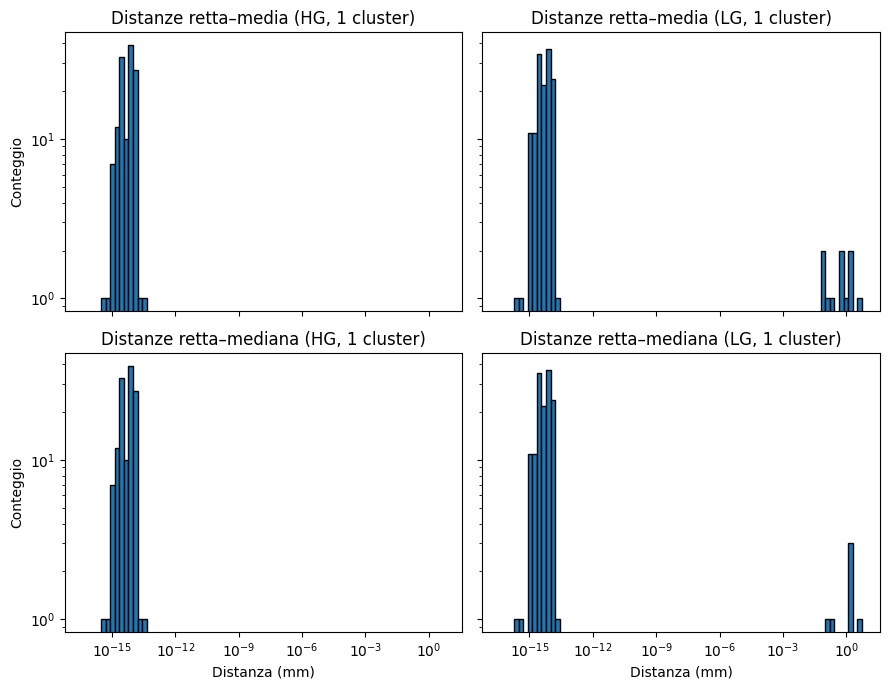

In [ ]:
# -------------------- SELEZIONE EVENTI CON 1 CLUSTER --------------------
# HG
eventi_cluster_hg = df_dist_hg.groupby(["event","mcrun"])["cluster"].nunique()
eventi_validi_hg = eventi_cluster_hg[eventi_cluster_hg == 1].index
df_sel_hg = df_dist_hg.set_index(["event","mcrun"]).loc[eventi_validi_hg].reset_index()

# LG
eventi_cluster_lg = df_dist_lg.groupby(["event","mcrun"])["cluster"].nunique()
eventi_validi_lg = eventi_cluster_lg[eventi_cluster_lg == 1].index
df_sel_lg = df_dist_lg.set_index(["event","mcrun"]).loc[eventi_validi_lg].reset_index()

# -------------------- ESTRAZIONE DISTANZE --------------------
d_mean_hg   = df_sel_hg["d_mean"].values
d_median_hg = df_sel_hg["d_median"].values
d_mean_lg   = df_sel_lg["d_mean"].values
d_median_lg = df_sel_lg["d_median"].values

# filtro valori validi (>0 e finiti)
d_mean_hg   = d_mean_hg[np.isfinite(d_mean_hg) & (d_mean_hg > 0)]
d_median_hg = d_median_hg[np.isfinite(d_median_hg) & (d_median_hg > 0)]
d_mean_lg   = d_mean_lg[np.isfinite(d_mean_lg) & (d_mean_lg > 0)]
d_median_lg = d_median_lg[np.isfinite(d_median_lg) & (d_median_lg > 0)]

# -------------------- BINS COMUNI --------------------
d_all = np.concatenate([d_mean_hg, d_median_hg, d_mean_lg, d_median_lg])
bins = np.logspace(np.log10(d_all.min()), np.log10(d_all.max()), 80)

# -------------------- PLOT --------------------
fig, axes = plt.subplots(2, 2, figsize=(9, 7), sharex=True, sharey=True)

# HG
axes[0,0].hist(d_mean_hg, bins=bins, edgecolor='black')
axes[0,0].set_title("Distanze retta–media (HG, 1 cluster)")
axes[0,0].set_ylabel("Conteggio")

axes[1,0].hist(d_median_hg, bins=bins, edgecolor='black')
axes[1,0].set_title("Distanze retta–mediana (HG, 1 cluster)")
axes[1,0].set_ylabel("Conteggio")
axes[1,0].set_xlabel("Distanza (mm)")

# LG
axes[0,1].hist(d_mean_lg, bins=bins, edgecolor='black')
axes[0,1].set_title("Distanze retta–media (LG, 1 cluster)")

axes[1,1].hist(d_median_lg, bins=bins, edgecolor='black')
axes[1,1].set_title("Distanze retta–mediana (LG, 1 cluster)")
axes[1,1].set_xlabel("Distanza (mm)")

# scala log
for ax in axes.flat:
    ax.set_xscale("log")
    ax.set_yscale("log")

plt.tight_layout()
plt.show()

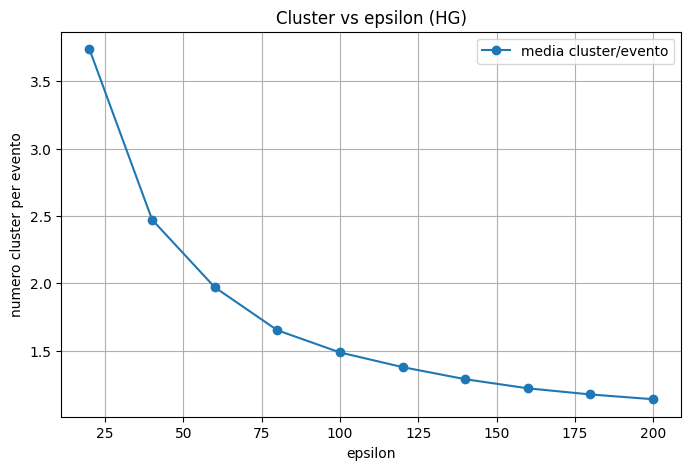

'\np0_list, p1_list, p2_list = [], [], []\nfor counts in n_cluster_per_event:\n    counts = np.array(counts)\n    total = len(counts)\n    p0_list.append(np.sum(counts==0)/total)\n    p1_list.append(np.sum(counts==1)/total)\n    p2_list.append(np.sum(counts==2)/total)\n\nplt.figure(figsize=(8,5))\nplt.plot(eps_values, p0_list, \'o-\', label="P(0 cluster)")\nplt.plot(eps_values, p1_list, \'s-\', label="P(1 cluster)")\nplt.plot(eps_values, p2_list, \'x-\', label="P(2 cluster)")\nplt.xlabel("epsilon")\nplt.ylabel("Probabilità eventi")\nplt.title("Probabilità di n cluster vs epsilon (HG)")\nplt.legend()\nplt.grid(True)\nplt.show()\n'

In [36]:
### STUDIO DELL'EPSILON PER DBSCAN------------------------------------------------
#variare eps su un intervallo, e per ogni valore calcolare:
#numero medio di cluster per evento numero di eventi con 0 cluster distribuzione dei cluster
eps_values = np.linspace(20, 200, 10)  # prova eps da 1 a 20
n_cluster_per_event = []

for eps in eps_values:
    cluster_counts = []
    for (event, mcrun), df_evt in df_int_hg.groupby(["event","mcrun"]):
        P = np.vstack(df_evt["P"].values)
        if len(P) == 0:
            continue
        labels = DBSCAN(eps=eps, min_samples=1).fit_predict(P)
        cl_labels = set(labels) - {-1}
        cluster_counts.append(len(cl_labels))
    n_cluster_per_event.append(cluster_counts)

# calcolo statistiche
mean_clusters = [np.mean(x) if len(x)>0 else 0 for x in n_cluster_per_event]
#median_clusters = [np.median(x) if len(x)>0 else 0 for x in n_cluster_per_event]

# plot
plt.figure(figsize=(8,5))
plt.plot(eps_values, mean_clusters, marker='o', label="media cluster/evento")
#plt.plot(eps_values, median_clusters, marker='x', label="mediana cluster/evento")
plt.xlabel("epsilon")
plt.ylabel("numero cluster per evento")
plt.title("Cluster vs epsilon (HG)")
plt.legend()
plt.grid(True)
plt.show()
###################################################################################################
#distribuzione dei cluster
'''
plt.figure(figsize=(8,5))
for eps, counts in zip(eps_values, n_cluster_per_event):
    plt.hist(counts, bins=np.arange(0, max(map(max,n_cluster_per_event))+2)-0.5,
             alpha=0.3, label=f"eps={eps:.1f}")
plt.xlabel("numero cluster per evento")
plt.ylabel("conteggio eventi")
plt.title("Distribuzione cluster/evento per diversi eps (HG)")
plt.legend()
plt.show()
'''
##########################################################################
#Per ogni epsilon puoi anche calcolare P(0 cluster), P(1 cluster), …
'''
p0_list, p1_list, p2_list = [], [], []
for counts in n_cluster_per_event:
    counts = np.array(counts)
    total = len(counts)
    p0_list.append(np.sum(counts==0)/total)
    p1_list.append(np.sum(counts==1)/total)
    p2_list.append(np.sum(counts==2)/total)

plt.figure(figsize=(8,5))
plt.plot(eps_values, p0_list, 'o-', label="P(0 cluster)")
plt.plot(eps_values, p1_list, 's-', label="P(1 cluster)")
plt.plot(eps_values, p2_list, 'x-', label="P(2 cluster)")
plt.xlabel("epsilon")
plt.ylabel("Probabilità eventi")
plt.title("Probabilità di n cluster vs epsilon (HG)")
plt.legend()
plt.grid(True)
plt.show()
'''

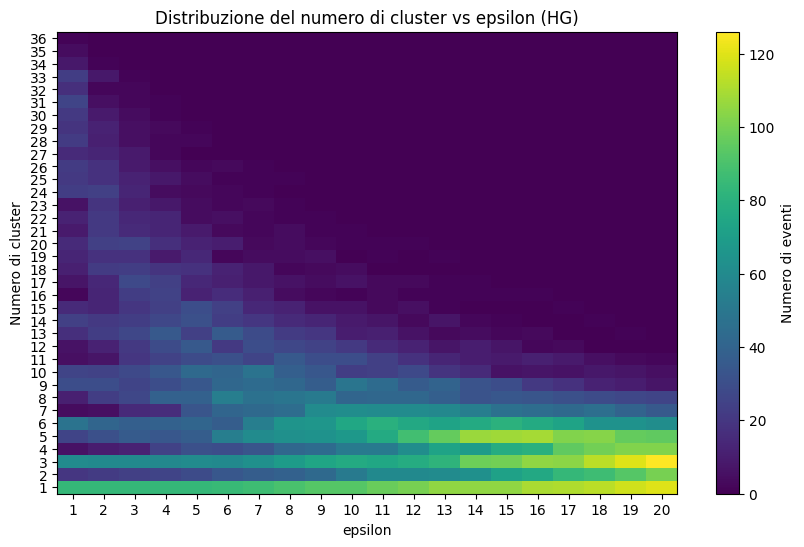

In [ ]:

eps_values = np.arange(1, 21, 1)  # epsilon da 1 a 20
min_samples = 1

results_eps = []

for eps in eps_values:
    cluster_counts = []

    for (event, mcrun), df_evt in df_int_hg.groupby(["event", "mcrun"]):

        P = np.vstack(df_evt["P"].values)

        if len(P) < min_samples:
            continue

        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(P)

        cl_labels = set(labels)
        cl_labels.discard(-1)
        n_clusters = len(cl_labels)

        cluster_counts.append(n_clusters)

    # distribuzione: n_clusters -> quante volte compare
    if len(cluster_counts) == 0:
        continue
    unique, counts = np.unique(cluster_counts, return_counts=True)

    for n_cl, cnt in zip(unique, counts):
        results_eps.append({
            "epsilon": eps,
            "n_clusters": n_cl,
            "count": cnt
        })

df_eps_dist = pd.DataFrame(results_eps)

# pivot per heatmap
pivot = df_eps_dist.pivot(index="n_clusters", columns="epsilon", values="count").fillna(0)

plt.figure(figsize=(10, 6))
plt.imshow(pivot, aspect="auto", origin="lower", cmap="viridis")
plt.colorbar(label="Numero di eventi")
plt.xlabel("epsilon")
plt.ylabel("Numero di cluster")
plt.title("Distribuzione del numero di cluster vs epsilon (HG)")
plt.xticks(ticks=np.arange(len(pivot.columns)), labels=pivot.columns)
plt.yticks(ticks=np.arange(len(pivot.index)), labels=pivot.index)
plt.show()

In [ ]:
#itero il processo per min_sample= 1,2 ,3,4

eps_values = np.arange(1, 21, 1)
min_samples_list = [1, 2, 3, 4]

results_all = []

for min_samp in min_samples_list:
    for eps in eps_values:
        cluster_counts = []

        for (event, mcrun), df_evt in df_int_hg.groupby(["event", "mcrun"]):

            P = np.vstack(df_evt["P"].values)

            if len(P) < min_samp:
                continue

            dbscan = DBSCAN(eps=eps, min_samples=min_samp)
            labels = dbscan.fit_predict(P)

            cl_labels = set(labels)
            cl_labels.discard(-1)
            n_clusters = len(cl_labels)

            cluster_counts.append(n_clusters)

        unique, counts = np.unique(cluster_counts, return_counts=True)

        for n_cl, cnt in zip(unique, counts):
            results_all.append({
                "min_samples": min_samp,
                "epsilon": eps,
                "n_clusters": n_cl,
                "count": cnt
            })

df_eps_dist = pd.DataFrame(results_all)


/tmp/ipykernel_2627/3106517223.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 0.95])


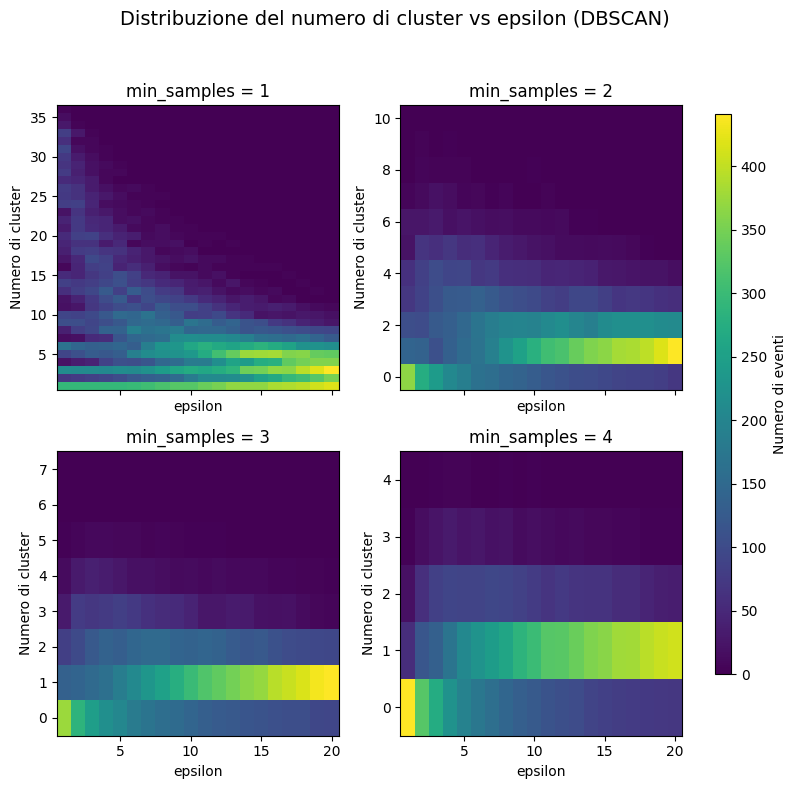

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8), sharex=True, sharey=False)
axes = axes.flatten()

for ax, min_samp in zip(axes, min_samples_list):
    df_sub = df_eps_dist[df_eps_dist["min_samples"] == min_samp]
    pivot = df_sub.pivot(index="n_clusters", columns="epsilon", values="count").fillna(0)

    eps_vals = pivot.columns.values
    ncl_vals = pivot.index.values

    im = ax.pcolormesh(eps_vals, ncl_vals, pivot.values, shading="auto")
    ax.set_title(f"min_samples = {min_samp}")
    ax.set_xlabel("epsilon")
    ax.set_ylabel("Numero di cluster")
    #ax.set_xticks(ticks=np.arange(len(pivot.columns)), labels=pivot.columns)
    #ax.set_yticks(ticks=np.arange(len(pivot.index)), labels=pivot.index)
# spazio per la colorbar a destra
fig.subplots_adjust(right=0.88)
cax = fig.add_axes([0.9, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cax, label="Numero di eventi")

plt.suptitle("Distribuzione del numero di cluster vs epsilon (DBSCAN)", fontsize=14)
plt.tight_layout(rect=[0, 0, 0.88, 0.95])
plt.show()


In [ ]:
import random
#vediamo due eventi presi casualmente
groups = list(df_all_sorted.groupby(["EVENT", "MCRUN"]))
random.shuffle(groups)
groups_A = groups[:len(groups)//2]
groups_B = groups[len(groups)//2:len(groups)]


fake_events = []

for i, ((evtA, dfA), (evtB, dfB)) in enumerate(zip(groups_A, groups_B)):
    if len(dfA) < 3 or len(dfB) < 3:
        continue

    #prendi almeno 3 telescopi da A e non più di quelli disponibili
    nA = max(3, len(dfA) // 2)
    nA = min(nA, len(dfA))
    partA = dfA.sample(n=nA, replace=False)

    #prendi almeno 3 telescopi da B e non più di quelli disponibili
    nB = max(3, len(dfB) // 2)
    nB = min(nB, len(dfB))
    partB = dfB.sample(n=nB, replace=False)

    # unione -> evento fittizio
    df_fake = pd.concat([partA, partB], ignore_index=True)
  
    # etichetta evento fittizio
    df_fake["FAKE_EVENT"] = i
    
    fake_events.append(df_fake)
#dataframe con tutti eventi fittizi
df_fake_all = pd.concat(fake_events, ignore_index=True)
df_fake_all.columns


Index(['TIME_NS', 'TIME_S', 'TIME_ABS', 'EVENT', 'MCRUN', 'TEL_ID', 'num_tel',
       'HG', 'LG', 'TTP', 'shape', 'FAKE_EVENT'],
      dtype='object')

In [ ]:
#########ora stessa analisi di sopra
xfp, yfp = at.utils.camera.get_xy_footprint()
y_pix, x_pix = at.utils.camera.get_pixels_position_matrix().T
x_pix = at.reshape(x_pix)
y_pix = at.reshape(y_pix)

#rette_hg=[]
#rette_lg=[]
results_f = []

for fevent, df_evt in df_fake_all.groupby(["FAKE_EVENT"]):

    for iv, row in df_evt.iterrows():

        itel = row["TEL_ID"]
        hgev = np.array(row["HG"])
        lgev = np.array(row["LG"])
        ttpev = np.array(row["TTP"])

        # filtro temporale
        pxmask = (hgev > 2400) & (ttpev < 255)
        if  np.sum(pxmask) == 0:
            continue
        # SIGMA-CLIPPING
    
        xx = x_pix[pxmask].flatten()
        yy = y_pix[pxmask].flatten()
        w_hg = hgev[pxmask].flatten()
        w_lg = lgev[pxmask].flatten()

        mx0 = np.average(xx, weights=w_hg)
        my0 = np.average(yy, weights=w_hg)

        r = np.sqrt((xx - mx0)**2 + (yy - my0)**2)

        r_clip, low, high = sc.sigmaclip(r, low=2., high=2.)
        keep = (r >= low) & (r <= high)

        xx_sc = xx[keep]
        yy_sc = yy[keep]
        w_hg_sc = w_hg[keep]
        w_lg_sc = w_lg[keep]
        # ---------- centroidi ----------
        meanx_hg = np.average(xx_sc, weights=w_hg_sc)
        meany_hg = np.average(yy_sc, weights=w_hg_sc)

        meanx_lg = np.average(xx_sc, weights=w_lg_sc)
        meany_lg = np.average(yy_sc, weights=w_lg_sc)

        # ---------- covarianze ----------
        cov_hg = np.cov([xx_sc, yy_sc], aweights=w_hg_sc)
        cov_lg = np.cov([xx_sc, yy_sc], aweights=w_lg_sc)
        # autovalori + direzione
        def principal_axis(cov):
            l1 = (cov[0,0] + cov[1,1])/2 + np.sqrt(
                ((cov[0,0] - cov[1,1])/2)**2 + cov[0,1]**2)
            theta = np.arctan2(l1 - cov[0,0], cov[0,1])
            return l1, theta

        l1_hg, theta_hg = principal_axis(cov_hg)
        l1_lg, theta_lg = principal_axis(cov_lg)

        results_f.append({
            "r_event": np.array([row["MCRUN"],row["EVENT"]]),
            "fevent": fevent,   
            "HG": {
                "p0": np.array([meanx_hg, meany_hg]),
                "d":  np.array([np.cos(theta_hg), np.sin(theta_hg)]),
                "l1": l1_hg,
                "tel": itel
            },
            "LG": {
                "p0": np.array([meanx_lg, meany_lg]),
                "d":  np.array([np.cos(theta_lg), np.sin(theta_lg)]),
                "l1": l1_lg,
                "tel": itel
            }
        })


In [ ]:
inters_hg_f = []
dist_hg_f=[]
inters_lg_f = []
dist_lg_f=[]
dfR_f=pd.DataFrame(results_f)
for fevent, df_evt in dfR_f.groupby("fevent"):

    rette_evth = df_evt["HG"].values
    rette_evtl = df_evt["LG"].values

    #per hg
    for i in range(len(rette_evth)):
        tel1 = rette_evth[i]["tel"]
        for j in range(i+1, len(rette_evth)):
            tel2 = rette_evth[j]["tel"]
            if tel1 == tel2: #controllo: no più telescopi nello stesso evento
                continue
    
            P = intersection(rette_evth[i]["p0"], rette_evth[i]["d"],
                             rette_evth[j]["p0"], rette_evth[j]["d"])
            if P is None :
                continue
            #'''
            #butto i punti troppo lontani
            r = np.linalg.norm(P)
            if r > 400:
                continue
            #'''
            #d1 = rette_evth[i]["d"]
            #d2 = rette_evth[j]["d"]
            #w = peso_angolare(d1, d2)
            #if w < 1e-3:   # rette quasi parallele
                #continue
            centro_hg=np.mean(P,axis=0)
            median_hg=np.median(P,axis=0)
            d_mean = []
            d_median = []

            for r in rette_evth:
                p0 = r["p0"]
                d  = r["d"]

                d_mean.append(d_punto_retta(centro_hg, p0, d))
                d_median.append(d_punto_retta(median_hg, p0, d))

            if P is not None:
                dist_hg_f.append({
                    "fevent":fevent,
                    "event": event,
                    "mcrun": mcrun,
                    "d_mean":d_mean,
                    "d_median":d_median

                })
                inters_hg_f.append({
                    "fevent":fevent,
                    "event": event,
                    "mcrun": mcrun,
                    "P": P
                })
    ###ora per lg
    for i in range(len(rette_evtl)):
        tel1 = rette_evtl[i]["tel"]
        for j in range(i+1, len(rette_evtl)):
            tel2 = rette_evtl[j]["tel"]
            if tel1 == tel2: #controllo: no più telescopi nello stesso evento
                continue
                
            P = intersection(rette_evtl[i]["p0"], rette_evtl[i]["d"],
                             rette_evtl[j]["p0"], rette_evtl[j]["d"])
            centro_lg=np.mean(P,axis=0)
            median_lg=np.median(P,axis=0)
            d_mean = []
            d_median = []
            r = np.linalg.norm(P)
            if r > 400:
                continue
            for r in rette_evtl:
                p0 = r["p0"]
                d  = r["d"]

                d_mean.append(d_punto_retta(centro_lg, p0, d))
                d_median.append(d_punto_retta(median_lg, p0, d))


            
            if P is not None:
                dist_lg_f.append({
                    "fevent":fevent,
                    "event": event,
                    "mcrun": mcrun,
                    "d_mean":d_mean,
                    "d_median":d_median

                })
                inters_lg_f.append({
                    "fevent":fevent,
                    "event": event,
                    "mcrun": mcrun,
                    "P": P
                })

df_int_hg = pd.DataFrame(inters_hg_f)
df_int_lg = pd.DataFrame(inters_lg_f)
df_dist_hg = pd.DataFrame(dist_hg_f)
df_dist_lg = pd.DataFrame(dist_lg_f)
P_hg = np.vstack(df_int_hg["P"].values)
P_lg = np.vstack(df_int_lg["P"].values)


In [ ]:
epsilon = 5
min_samples = 1

results_clusters = []

for fevent, df_evt in df_int_hg.groupby("fevent"):

    # punti di intersezione dell'evento
    P = np.vstack(df_evt["P"].values)

    if len(P) < min_samples:
        continue

    # DBSCAN
    dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
    labels = dbscan.fit_predict(P)

    # cluster validi (senza rumore)
    cl_labels = set(labels)
    cl_labels.discard(-1)
    n_clusters = len(cl_labels)

    if n_clusters == 0:
        results_clusters.append({
            "fevent": fevent,
            "n_clusters": 0,
            "HG_mean_dist": {},
            "HG_median_dist": {},
            "LG_mean_dist": {},
            "LG_median_dist": {}
        })
        continue

    # ===================== CENTRI CLUSTER =====================
    centri_mean = {}
    centri_median = {}

    for lab in cl_labels:
        pts = P[labels == lab]
        centri_mean[lab]   = np.mean(pts, axis=0)
        centri_median[lab] = np.median(pts, axis=0)

    # rette dell'evento
    dfR_evt = dfR_f[dfR_f["fevent"] == fevent]

    # dizionari: cluster --> lista distanze
    r_median_HG = {lab: [] for lab in cl_labels}
    r_mean_HG   = {lab: [] for lab in cl_labels}
    r_median_LG = {lab: [] for lab in cl_labels}
    r_mean_LG   = {lab: [] for lab in cl_labels}

    # ===================== HG =====================
    for r in dfR_evt["HG"]:
        p0 = r["p0"]
        d  = r["d"]

        norm_d = np.linalg.norm(d)
        if norm_d == 0:
            continue
        d_unit = d / norm_d

        for lab in cl_labels:
            c_mean = centri_mean[lab]
            c_med  = centri_median[lab]

            v_mean = c_mean - p0
            v_med  = c_med  - p0

            dist_mean   = abs(v_mean[0] * d_unit[1] - v_mean[1] * d_unit[0])
            dist_median = abs(v_med[0]  * d_unit[1] - v_med[1]  * d_unit[0])

            r_mean_HG[lab].append(dist_mean)
            r_median_HG[lab].append(dist_median)

    # ===================== LG =====================
    for r in dfR_evt["LG"]:
        p0 = r["p0"]
        d  = r["d"]

        norm_d = np.linalg.norm(d)
        if norm_d == 0:
            continue
        d_unit = d / norm_d

        for lab in cl_labels:
            c_mean = centri_mean[lab]
            c_med  = centri_median[lab]

            v_mean = c_mean - p0
            v_med  = c_med  - p0

            dist_mean   = abs(v_mean[0] * d_unit[1] - v_mean[1] * d_unit[0])
            dist_median = abs(v_med[0]  * d_unit[1] - v_med[1]  * d_unit[0])

            r_mean_LG[lab].append(dist_mean)
            r_median_LG[lab].append(dist_median)

    # rimuovo cluster vuoti + converto in array
    r_median_HG = {lab: np.array(v) for lab, v in r_median_HG.items() if len(v) > 0}
    r_mean_HG   = {lab: np.array(v) for lab, v in r_mean_HG.items()   if len(v) > 0}
    r_median_LG = {lab: np.array(v) for lab, v in r_median_LG.items() if len(v) > 0}
    r_mean_LG   = {lab: np.array(v) for lab, v in r_mean_LG.items()   if len(v) > 0}

    results_clusters.append({
        "fevent": fevent,
        "n_clusters": n_clusters,
        "HG_mean_dist": r_mean_HG,
        "HG_median_dist": r_median_HG,
        "LG_mean_dist": r_mean_LG,
        "LG_median_dist": r_median_LG,
        "P_mean": centri_mean,
        "P_median": centri_median,
        "n_HG_lines": len(dfR_evt["HG"]),
        "n_LG_lines": len(dfR_evt["LG"])
    })


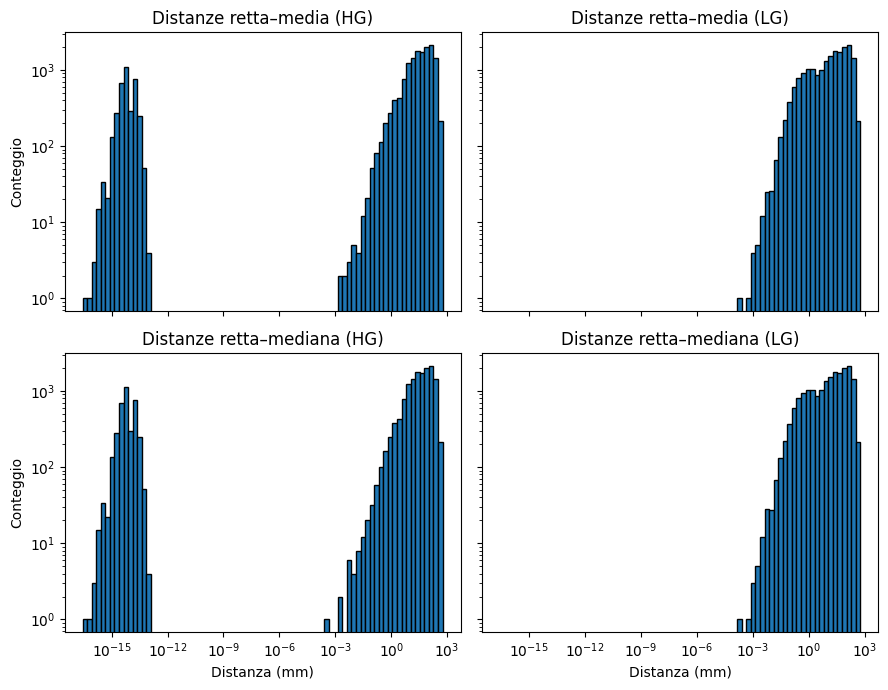

In [26]:
# Estraggo tutte le distanze HG e LG (media e mediana) da results_clusters

d_mean_hg = []
d_median_hg = []
d_mean_lg = []
d_median_lg = []

for res in results_clusters:
    for vals in res["HG_mean_dist"].values():
        d_mean_hg.extend(vals)
    for vals in res["HG_median_dist"].values():
        d_median_hg.extend(vals)
    for vals in res["LG_mean_dist"].values():
        d_mean_lg.extend(vals)
    for vals in res["LG_median_dist"].values():
        d_median_lg.extend(vals)

d_mean_hg = np.array(d_mean_hg)
d_median_hg = np.array(d_median_hg)
d_mean_lg = np.array(d_mean_lg)
d_median_lg = np.array(d_median_lg)

# filtro > 0
d_mean_hg = d_mean_hg[d_mean_hg > 0]
d_median_hg = d_median_hg[d_median_hg > 0]
d_mean_lg = d_mean_lg[d_mean_lg > 0]
d_median_lg = d_median_lg[d_median_lg > 0]

# binnaggio comune
d_all = np.concatenate([d_mean_hg, d_median_hg, d_mean_lg, d_median_lg])
bins = np.logspace(np.log10(d_all.min()), np.log10(d_all.max()), 80)

fig, axes = plt.subplots(2, 2, figsize=(9, 7), sharex=True, sharey=True)

# -------------------- HG --------------------
axes[0,0].hist(d_mean_hg, bins=bins, edgecolor='black')
axes[0,0].set_title("Distanze retta–media (HG)")
axes[0,0].set_ylabel("Conteggio")

axes[1,0].hist(d_median_hg, bins=bins, edgecolor='black')
axes[1,0].set_title("Distanze retta–mediana (HG)")
axes[1,0].set_ylabel("Conteggio")
axes[1,0].set_xlabel("Distanza (mm)")

# -------------------- LG --------------------
axes[0,1].hist(d_mean_lg, bins=bins, edgecolor='black')
axes[0,1].set_title("Distanze retta–media (LG)")

axes[1,1].hist(d_median_lg, bins=bins, edgecolor='black')
axes[1,1].set_title("Distanze retta–mediana (LG)")
axes[1,1].set_xlabel("Distanza (mm)")

# scala log per tutti
for ax in axes.flat:
    ax.set_xscale("log")
    ax.set_yscale("log")

plt.tight_layout()
plt.show()


In [28]:
rows = []

for ev in results_clusters:
    fevent = ev["fevent"]
    ncl    = ev["n_clusters"]

    for channel in ["HG", "LG"]:
        for center in ["mean", "median"]:
            dist_dict = ev[f"{channel}_{center}_dist"]

            for cl, dist_arr in dist_dict.items():
                for d in dist_arr:
                    if np.isfinite(d) and d > 0:
                        rows.append({
                            "fevent": fevent,
                            "n_clusters": ncl,
                            "cluster": cl,
                            "channel": channel,
                            "center": center,
                            "distance": d
                        })

df_dist = pd.DataFrame(rows)
#distanze log
df_dist["log_distance"] = np.log10(df_dist["distance"])
stats_global = (df_dist.groupby(["channel","center"])["distance"].describe())
print(stats_global)

                  count       mean        std           min       25%  \
channel center                                                          
HG      mean    17877.0  58.530859  80.221977  2.775558e-17  1.398122   
        median  17840.0  58.650760  80.264282  2.775558e-17  1.442482   
LG      mean    19271.0  54.873786  78.610776  2.332601e-04  1.605527   
        median  19271.0  54.874510  78.612520  2.332601e-04  1.601248   

                      50%        75%         max  
channel center                                    
HG      mean    21.582573  86.935675  572.035726  
        median  21.699005  87.122563  572.035726  
LG      mean    17.382296  78.930833  572.298696  
        median  17.382296  78.937125  572.298696  


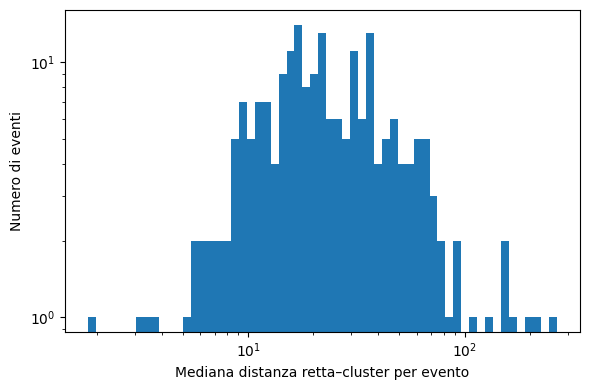

In [33]:
evt_dist = (
    df_dist
    .groupby("fevent")["distance"]
    .median()
)

# filtro sicurezza
evt_dist = evt_dist[np.isfinite(evt_dist) & (evt_dist > 0)]

# bin logaritmici
bins = np.logspace(
    np.log10(evt_dist.min()),
    np.log10(evt_dist.max()),
    60
)

plt.figure(figsize=(6,4))
plt.hist(evt_dist, bins=bins)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Mediana distanza retta–cluster per evento")
plt.ylabel("Numero di eventi")
plt.tight_layout()
plt.show()

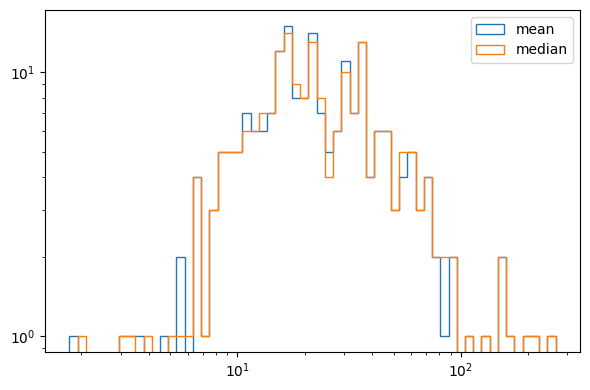

In [34]:
evt_mean = (
    df_dist[df_dist.center == "mean"]
    .groupby("fevent")["distance"]
    .median()
)

evt_median = (
    df_dist[df_dist.center == "median"]
    .groupby("fevent")["distance"]
    .median()
)

evt_mean   = evt_mean[evt_mean > 0]
evt_median = evt_median[evt_median > 0]

bins = np.logspace(
    np.log10(min(evt_mean.min(), evt_median.min())),
    np.log10(max(evt_mean.max(), evt_median.max())),
    60
)

plt.figure(figsize=(6,4))
plt.hist(evt_mean, bins=bins, histtype="step", label="mean")
plt.hist(evt_median, bins=bins, histtype="step", label="median")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()
